Project Title: The Marvel Multiverse: A Data-Driven Analysis of Cinematic Success
The Goal: Analyze what factors make a Marvel project successful by looking at the relationships between different cinematic universes, cast popularity, budgets, and audience/critic ratings.

1. Data Cleaning & Preparation (The Unsung Hero Stage)
The Issue: Looking at marvel_master.csv, you'll notice many missing values in fields like budget_usd, revenue_usd, box_office_usd, and scores.

Your Task: Handle these missing values. Will you drop rows with missing financial data, fill them with zeros, or use a median?

Categorical Encoding: Clean up the categorical columns like mcu_phase and universe. Standardize them so you don't have messy text groupings.

In [1]:
import pandas as pd
master= pd.read_csv('marvel_master.csv')
cast= pd.read_csv('marvel_cast.csv')
ratings= pd.read_csv('marvel_ratings.csv')
rag= pd.read_csv('marvel_rag.csv')

cast.head()

,title,year,tmdb_id,actor_name,character,cast_order,actor_tmdb_id,popularity,profile_path
0,Captain America,1944,106355.0,Dick Purcell,Captain America / Grant Gardner,0,13970,0.3970,https://image.tmdb.org/t/p/w185/p0RZAW7uh1dIwu...
1,Captain America,1944,106355.0,Lorna Gray,Gail Richards,1,96719,0.4055,https://image.tmdb.org/t/p/w185/cdWxxF7weiJucc...
2,Captain America,1944,106355.0,Lionel Atwill,Cyrus Maldor,2,2495,0.4445,https://image.tmdb.org/t/p/w185/2KFwXY3fsMWWye...
3,Captain America,1944,106355.0,Charles Trowbridge,Police Commissioner Dryden,3,96721,0.3023,https://image.tmdb.org/t/p/w185/l0pMZJiTfkxBOE...
4,Captain America,1944,106355.0,Russell Hicks,Mayor Randolph,4,13969,0.8038,https://image.tmdb.org/t/p/w185/5Pir7aPr3Iooqd...


In [2]:

import numpy as np
def convert_to_numeric(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')
        return df
    convert_to_numeric(master, ['budget_usd', 'scores', 'box_office_usd', 'revenue_usd'])

convert_to_numeric(master, ['budget_usd', 'scores', 'box_office_usd', 'revenue_usd'])

def convert_to_string(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = df[column].astype(str)
    return df

convert_to_string(master, ['imdb_id', 'type', 'genre','director','writer','actors','decade','tmdb_genres','top5_cast','poster_url'])

def replace_missing_values(df, columns, value):
    for column in columns:
        if column in df.columns:
            df[column].fillna(value, inplace=True)
    return df
replace_missing_values(master, ['budget_usd', 'scores', 'box_office_usd', 'revenue_usd','runtime_min','imdb_rating','imdb_votes','rt_score'
                                , 'metacritic_score','tmdb_id','tmdb_rating','tmdb_votes','popularity'], 0)

replace_missing_values(master, ['imdb_id', 'genre','writer','actors','decade','tmdb_genres','top5_cast','poster_url'], 'Nil')
replace_missing_values(master, ['plot','directors','producers','composer','tmdb_keywords','collection_name','tagline',
                                'episode_count','season_count', 'type'], 'Unknown')
replace_missing_values(master, ['awards'], 'Not Nominated')
replace_missing_values(master, ['rated'], 'Family')
replace_missing_values(master, ['spoken_languages'], 'English')
replace_missing_values(master, ['country','production_countries'], 'United States')
replace_missing_values(master, ['status'],'Forgotten')
replace_missing_values(master, ['network'], 'Disney+')

def to_category(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = df[column].astype('category')
    return df
to_category(master,['mcu_phase','status','type', 'is_animated','is_tv_series','is_mcu_canon','universe'])

def drop_columns(df, columns):
    for column in columns:
        if column in df.columns:
            df.drop(columns=[column], inplace=True)
    return df
drop_columns(master, ['website','production','language','director'])
def to_object(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = df[column].astype('object')
    return df

def to_integer(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = df[column].astype(int)
    return df
to_integer(master, ['year'])

def categorise(df, condition, choices, column_name='Era'):
    df[column_name] = np.select(condition, choices, default='Unknown')
    return df

condition = [
    master['year'] < 2000,
    (master['year'] >= 2000) & (master['year'] <= 2025),
    master['year'] == 2026
]
era = ['Classic', 'Modern', 'Current']

categorise(master, condition, era, column_name='Era')
to_category(master, ['Era'])
to_category(rag,['universe', 'mcu_phase'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_12844\1868672244.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[column].fillna(value, inplace=True)


,id,title,year,universe,mcu_phase,document
0,1,Captain America,1944,Pre-MCU,Pre-MCU,Title: Captain America\nYear: 1944\nUniverse: ...
1,2,The Amazing Spider-Man,1977,Sony / Spider-Man,Pre-MCU,Title: The Amazing Spider-Man\nYear: 1977\nUni...
2,3,Spider-Man,1977,Sony / Spider-Man,Pre-MCU,Title: Spider-Man\nYear: 1977\nUniverse: Sony ...
3,4,Dr. Strange,1978,Pre-MCU,Pre-MCU,Title: Dr. Strange\nYear: 1978\nUniverse: Pre-...
4,5,The Incredible Hulk,1978,Pre-MCU,Pre-MCU,Title: The Incredible Hulk\nYear: 1978\nUniver...
...,...,...,...,...,...,...
156,157,Venom: The Last Dance,2025,Sony / Spider-Man,Phase 5/6,Title: Venom: The Last Dance\nYear: 2025\nUniv...
157,158,Kraven the Hunter,2025,Sony / Spider-Man,Phase 5/6,Title: Kraven the Hunter\nYear: 2025\nUniverse...
158,159,Wonder Man,2026,MCU,Phase 5/6,Title: Wonder Man\nYear: 2026\nUniverse: MCU\n...
159,160,Daredevil: Born Again,2026,MCU,Phase 5/6,Title: Daredevil: Born Again\nYear: 2026\nUniv...


2. Joining Data (Connecting the Pieces)
Your Task: Bring in external context. Use pandas merges to join marvel_master.csv with the other files:

The Cast Connection: Group the marvel_cast.csv by movie to find the average actor popularity or the number of high-profile stars in a movie, then merge that summary dataframe back into your master dataset.

The Ratings Merge: Compare how different review platforms scale their ratings by checking marvel_ratings.csv.

In [3]:
def merge_df(df1, df2, on_column, how, suffixes):
    merged_df = pd.merge(df1, df2, on=on_column, how=how, suffixes=suffixes)
    return merged_df
merged_df = merge_df(master, cast, on_column='title', how='left', suffixes=('', '_cast'))
merged_df

,id,title,year,imdb_id,type,rated,runtime_min,genre,writer,actors,...,tagline,Era,year_cast,tmdb_id_cast,actor_name,character,cast_order,actor_tmdb_id,popularity_cast,profile_path
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,Classic,1944.0,106355.0,Dick Purcell,Captain America / Grant Gardner,0.0,13970.0,0.3970,https://image.tmdb.org/t/p/w185/p0RZAW7uh1dIwu...
1,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,Classic,1944.0,106355.0,Lorna Gray,Gail Richards,1.0,96719.0,0.4055,https://image.tmdb.org/t/p/w185/cdWxxF7weiJucc...
2,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,Classic,1944.0,106355.0,Lionel Atwill,Cyrus Maldor,2.0,2495.0,0.4445,https://image.tmdb.org/t/p/w185/2KFwXY3fsMWWye...
3,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,Classic,1944.0,106355.0,Charles Trowbridge,Police Commissioner Dryden,3.0,96721.0,0.3023,https://image.tmdb.org/t/p/w185/l0pMZJiTfkxBOE...
4,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,Classic,1944.0,106355.0,Russell Hicks,Mayor Randolph,4.0,13969.0,0.8038,https://image.tmdb.org/t/p/w185/5Pir7aPr3Iooqd...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,161,Spider-Man: Brand New Day,2026,tt22084616,movie,Family,0.0,"Action, Adventure, Fantasy","Chris McKenna, Erik Sommers, Stan Lee","Tom Holland, Zendaya, Sadie Sink",...,Unknown,Current,2026.0,969681.0,Eman Esfandi,NaN,10.0,2243207.0,0.3494,https://image.tmdb.org/t/p/w185/lrDfNC81vTkFW9...
2036,161,Spider-Man: Brand New Day,2026,tt22084616,movie,Family,0.0,"Action, Adventure, Fantasy","Chris McKenna, Erik Sommers, Stan Lee","Tom Holland, Zendaya, Sadie Sink",...,Unknown,Current,2026.0,969681.0,Keith David,NaN,11.0,65827.0,2.0395,https://image.tmdb.org/t/p/w185/1x0QXavmIy3Qmh...
2037,161,Spider-Man: Brand New Day,2026,tt22084616,movie,Family,0.0,"Action, Adventure, Fantasy","Chris McKenna, Erik Sommers, Stan Lee","Tom Holland, Zendaya, Sadie Sink",...,Unknown,Current,2026.0,969681.0,Zabryna Guevara,Sheila Rivera,12.0,171955.0,0.7338,https://image.tmdb.org/t/p/w185/7NlCmTZoauvyqj...
2038,161,Spider-Man: Brand New Day,2026,tt22084616,movie,Family,0.0,"Action, Adventure, Fantasy","Chris McKenna, Erik Sommers, Stan Lee","Tom Holland, Zendaya, Sadie Sink",...,Unknown,Current,2026.0,969681.0,Rosario Dawson,Claire Temple,13.0,5916.0,2.3905,https://image.tmdb.org/t/p/w185/1mm7JGHIUX3GRR...


In [4]:
replace_missing_values(cast, ['profile_path'], 'Nil')
#cast.head(50)
grouping= cast.groupby('title').agg({'popularity':'mean'}).sort_values(by='popularity',ascending=False)
grouping
merged_df = merge_df(master, grouping, on_column='title', how='left', suffixes=('', '_cast'))
merged_df

,id,title,year,imdb_id,type,rated,runtime_min,genre,writer,actors,...,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline,Era,popularity_cast
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,https://image.tmdb.org/t/p/w500/nBRcChS66NohR3...,United States of America,English,Unknown,Unknown,Disney+,Released,Unknown,Classic,0.595837
1,2,The Amazing Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",nan,"Nicholas Hammond, Robert F. Simon, Chip Fields",...,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,Unknown,Unknown,Disney+,Released,The world's favorite adventure super hero in l...,Classic,1.240443
2,3,Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",nan,"Nicholas Hammond, Robert F. Simon, Chip Fields",...,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,Unknown,Unknown,Disney+,Released,The world's favorite adventure super hero in l...,Classic,0.986493
3,4,Dr. Strange,1978,tt0077469,movie,TV-PG,93.0,"Action, Fantasy","Philip DeGuere Jr., Steve Ditko, Stan Lee","Peter Hooten, Clyde Kusatsu, Jessica Walter",...,https://image.tmdb.org/t/p/w500/hEyHVgBE28Jl13...,United States of America,English,Unknown,Unknown,Disney+,Released,Battle of the sorcerers burns the screen with ...,Classic,0.524300
4,5,The Incredible Hulk,1978,nan,nan,Family,0.0,nan,nan,nan,...,https://image.tmdb.org/t/p/w500/3apbGlabEmgR1j...,United States of America,English,Unknown,Unknown,Disney+,Released,She loved the man... would the beast destroy t...,Classic,1.061639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,157,Venom: The Last Dance,2025,nan,nan,Family,0.0,nan,nan,nan,...,https://image.tmdb.org/t/p/w500/vGXptEdgZIhPg3...,United States of America,English,Unknown,Unknown,Disney+,Released,'Til death do they part.,Modern,1.765047
157,158,Kraven the Hunter,2025,nan,nan,Family,0.0,nan,nan,nan,...,https://image.tmdb.org/t/p/w500/1GvBhRxY6MELDf...,United States of America,"English, Russian, Turkish",Unknown,Unknown,Disney+,Released,Villains aren't born. They're made.,Modern,1.024213
158,159,Wonder Man,2026,tt21066182,series,TV-14,0.0,"Action, Adventure, Comedy",Destin Daniel Cretton,"Yahya Abdul-Mateen II, Ben Kingsley, X Mayo",...,https://image.tmdb.org/t/p/w500/6yy9nQlFt2l6UV...,United States of America,English,8.0,2.0,Disney+,Returning Series,"He was born to play this role, but the spotlig...",Current,1.568075
159,160,Daredevil: Born Again,2026,tt40791652,movie,Family,0.0,Talk-Show,nan,nan,...,https://image.tmdb.org/t/p/w500/pXr32DqmkiEJTQ...,United States of America,English,9.0,1.0,"YouTube, Disney+",Returning Series,Unknown,Current,1.620962


In [5]:
ratings
replace_missing_values(ratings, ['score'], 0)
to_category(ratings, ['source'])

def strip(df, columns):
    for column in columns:
        if column in df.columns:
            df[column] = df[column].astype(str).str.replace(r'/100|%', '', regex=True).str.strip()
    return df
strip(ratings, ['score'])
convert_to_numeric(ratings, ['score'])

,title,year,source,score
0,Captain America,1944,IMDb,5.300
1,Captain America,1944,TMDB,5.400
2,The Amazing Spider-Man,1977,IMDb,6.200
3,The Amazing Spider-Man,1977,TMDB,6.300
4,Spider-Man,1977,IMDb,6.200
...,...,...,...,...
549,Wonder Man,2026,IMDb,7.400
550,Wonder Man,2026,TMDB,7.019
551,Daredevil: Born Again,2026,IMDb,7.800
552,Daredevil: Born Again,2026,TMDB,7.000


In [6]:
#grouped_ratings = ratings.groupby(['title']).agg({'score':'mean'}).sort_values(by='score',ascending=False)
#grouped_ratings
master

,id,title,year,imdb_id,type,rated,runtime_min,genre,writer,actors,...,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline,Era
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,https://image.tmdb.org/t/p/w500/nBRcChS66NohR3...,United States of America,English,Unknown,Unknown,Disney+,Released,Unknown,Classic
1,2,The Amazing Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",nan,"Nicholas Hammond, Robert F. Simon, Chip Fields",...,Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,Unknown,Unknown,Disney+,Released,The world's favorite adventure super hero in l...,Classic
2,3,Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",nan,"Nicholas Hammond, Robert F. Simon, Chip Fields",...,Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,Unknown,Unknown,Disney+,Released,The world's favorite adventure super hero in l...,Classic
3,4,Dr. Strange,1978,tt0077469,movie,TV-PG,93.0,"Action, Fantasy","Philip DeGuere Jr., Steve Ditko, Stan Lee","Peter Hooten, Clyde Kusatsu, Jessica Walter",...,Unknown,https://image.tmdb.org/t/p/w500/hEyHVgBE28Jl13...,United States of America,English,Unknown,Unknown,Disney+,Released,Battle of the sorcerers burns the screen with ...,Classic
4,5,The Incredible Hulk,1978,nan,nan,Family,0.0,nan,nan,nan,...,The Incredible Hulk Collection,https://image.tmdb.org/t/p/w500/3apbGlabEmgR1j...,United States of America,English,Unknown,Unknown,Disney+,Released,She loved the man... would the beast destroy t...,Classic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,157,Venom: The Last Dance,2025,nan,nan,Family,0.0,nan,nan,nan,...,Venom Collection,https://image.tmdb.org/t/p/w500/vGXptEdgZIhPg3...,United States of America,English,Unknown,Unknown,Disney+,Released,'Til death do they part.,Modern
157,158,Kraven the Hunter,2025,nan,nan,Family,0.0,nan,nan,nan,...,Unknown,https://image.tmdb.org/t/p/w500/1GvBhRxY6MELDf...,United States of America,"English, Russian, Turkish",Unknown,Unknown,Disney+,Released,Villains aren't born. They're made.,Modern
158,159,Wonder Man,2026,tt21066182,series,TV-14,0.0,"Action, Adventure, Comedy",Destin Daniel Cretton,"Yahya Abdul-Mateen II, Ben Kingsley, X Mayo",...,Unknown,https://image.tmdb.org/t/p/w500/6yy9nQlFt2l6UV...,United States of America,English,8.0,2.0,Disney+,Returning Series,"He was born to play this role, but the spotlig...",Current
159,160,Daredevil: Born Again,2026,tt40791652,movie,Family,0.0,Talk-Show,nan,nan,...,Unknown,https://image.tmdb.org/t/p/w500/pXr32DqmkiEJTQ...,United States of America,English,9.0,1.0,"YouTube, Disney+",Returning Series,Unknown,Current


3. Summary Statistics & Aggregation (Finding Patterns)
Your Task: Group the data by universe (e.g., MCU vs. Sony vs. Pre-MCU) or mcu_phase (Phase 1, Phase 2, etc.).

Metrics: Calculate the average budget, return on investment (ROI = Revenue / Budget), and mean IMDb/TMDB rating for each group.

In [7]:
grouping= master.groupby(['mcu_phase', 'universe'], sort=True).agg({'title':'count'}).sort_values(by='title',ascending=False)
grouping


C:\Users\DELL\AppData\Local\Temp\ipykernel_12844\3185412229.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouping= master.groupby(['mcu_phase', 'universe'], sort=True).agg({'title':'count'}).sort_values(by='title',ascending=False)


title
mcu_phase universe                
Pre-MCU   Pre-MCU               27
Non-MCU   MCU                   25
Phase 5/6 MCU                   22
Phase 4   MCU                   18
Non-MCU   Fox / X-Men           14
          Netflix Marvel        13
Phase 3   MCU                   11
Pre-MCU   Sony / Spider-Man      6
Non-MCU   Sony / Spider-Man      6
Phase 2   MCU                    6
Phase 1   MCU                    6
Pre-MCU   Fox / X-Men            3
Phase 5/6 Sony / Spider-Man      3
          Fox / X-Men            1
Phase 2   Fox / X-Men            0
Phase 1   Netflix Marvel         0
          Pre-MCU                0
Non-MCU   Pre-MCU                0
Phase 1   Fox / X-Men            0
Phase 3   Pre-MCU                0
          Netflix Marvel         0
          Fox / X-Men            0
Phase 2   Sony / Spider-Man      0
          Netflix Marvel         0
          Pre-MCU                0
Phase 1   Sony / Spider-Man      0
Phase 3   Sony / Spider-Man      0
Phase 4   Pre-MCU                0
          Sony / Spider-Man      0
          Fox / X-Men            0
          Netflix Marvel         0
Phase 5/6 Netflix Marvel         0
          Pre-MCU                0
Pre-MCU   Netflix Marvel         0
          MCU                    0

In [8]:
roi= master['revenue_usd'] / master['budget_usd']
average_budget= master['budget_usd'].mean()
mean_rating= master['tmdb_rating'].mean()

print(roi)
print(average_budget)
print(mean_rating)

date= pd.to_datetime(master['year'], errors='coerce').dt.year
date


0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
156    3.991147
157    0.477512
158         NaN
159         NaN
160         NaN
Length: 161, dtype: float64
74163975.1552795
4.763155279503106


0      1970
1      1970
2      1970
3      1970
4      1970
       ... 
156    1970
157    1970
158    1970
159    1970
160    1970
Name: year, Length: 161, dtype: int32

4. Correlation & Deep Dive (The Core EDA)
Your Task: Test assumptions using correlation.

Does a higher budget actually guarantee a higher box office return or a better rating?

Does a cast with a higher average popularity score lead to better movie ratings?

Visualizations: Create a correlation heatmap using seaborn to show these relationships instantly. Use matplotlib scatter plots to track Budget vs. Revenue or Box Office across different universes.

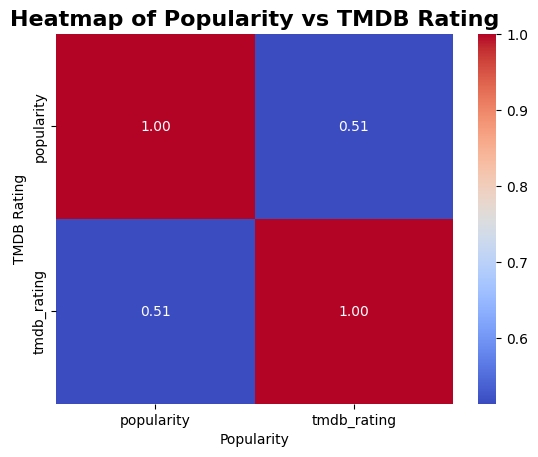

In [9]:
convert_to_numeric(master, ['popularity'])
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(data= master[['popularity','tmdb_rating']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Popularity vs TMDB Rating', fontsize= 16, fontweight= 'bold', color= 'black')
plt.xlabel('Popularity')
plt.ylabel('TMDB Rating')
plt.show()


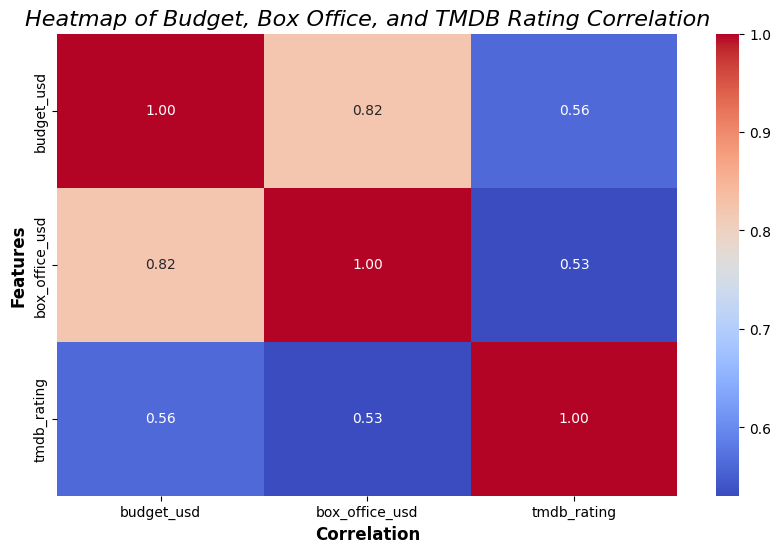

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(data= master[['budget_usd','box_office_usd','tmdb_rating']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Budget, Box Office, and TMDB Rating Correlation', fontsize= 16, fontstyle= 'italic', color= 'black')
ax.set_xlabel('Correlation', fontsize= 12, fontweight= 'bold', color= 'black')
ax.set_ylabel('Features', fontsize= 12, fontweight= 'bold', color= 'black')
plt.show()

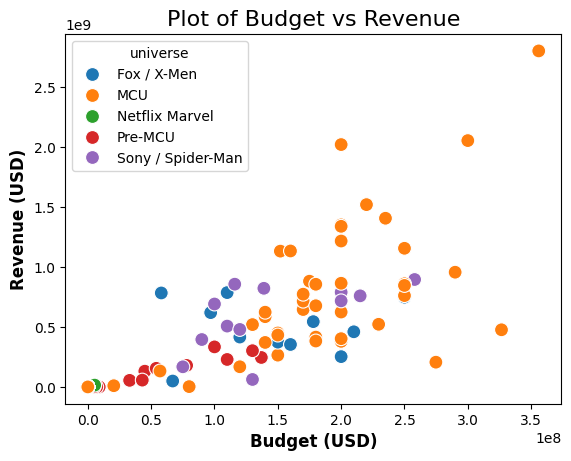

In [11]:
sns.scatterplot(data= master,x='budget_usd', y= 'revenue_usd',hue= 'universe', s= 100)
plt.title('Plot of Budget vs Revenue', fontsize= 16, color= 'black')
plt.xlabel('Budget (USD)', fontsize= 12, fontweight= 'bold', color= 'black')
plt.ylabel('Revenue (USD)', fontsize= 12, fontweight= 'bold', color= 'black')
plt.show()

In [12]:
import datetime as dt
master.head()
date= pd.to_datetime(master['year'], errors='coerce').dt.year
today= dt.date.today()
age_diff= today.year - master['year']
age_egu= age_diff == master['age_years']


In [13]:
master.head()

,id,title,year,imdb_id,type,rated,runtime_min,genre,writer,actors,...,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline,Era
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",...,Unknown,https://image.tmdb.org/t/p/w500/nBRcChS66NohR3...,United States of America,English,Unknown,Unknown,Disney+,Released,Unknown,Classic
1,2,The Amazing Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",nan,"Nicholas Hammond, Robert F. Simon, Chip Fields",...,Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,Unknown,Unknown,Disney+,Released,The world's favorite adventure super hero in l...,Classic
2,3,Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",nan,"Nicholas Hammond, Robert F. Simon, Chip Fields",...,Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,Unknown,Unknown,Disney+,Released,The world's favorite adventure super hero in l...,Classic
3,4,Dr. Strange,1978,tt0077469,movie,TV-PG,93.0,"Action, Fantasy","Philip DeGuere Jr., Steve Ditko, Stan Lee","Peter Hooten, Clyde Kusatsu, Jessica Walter",...,Unknown,https://image.tmdb.org/t/p/w500/hEyHVgBE28Jl13...,United States of America,English,Unknown,Unknown,Disney+,Released,Battle of the sorcerers burns the screen with ...,Classic
4,5,The Incredible Hulk,1978,nan,nan,Family,0.0,nan,nan,nan,...,The Incredible Hulk Collection,https://image.tmdb.org/t/p/w500/3apbGlabEmgR1j...,United States of America,English,Unknown,Unknown,Disney+,Released,She loved the man... would the beast destroy t...,Classic


In [20]:
import plotly.express as px

fig = px.scatter(
    master,
    x="budget_usd",
    y="revenue_usd",
    color="universe",
    hover_name="title",          # Movie/Series name
    size_max=15,
    opacity=0.8,
    title="Budget vs Revenue Across Marvel Universes",
    labels={
        "budget_usd": "Budget (USD)",
        "revenue_usd": "Revenue (USD)",
        "universe": "Universe"
    }
)

fig.update_traces(marker=dict(size=12))

fig.update_layout(
    title_x=0.5,
    width=900,
    height=600,
    legend_title="Universe"
)

fig.show()
fig.write_html("budget_vs_revenue.html")


In [19]:
import plotly.express as px

# Calculate correlation matrix
corr_matrix = master[['budget_usd', 'box_office_usd', 'tmdb_rating']].corr()

# Interactive heatmap
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="Correlation Between Budget, Box Office, and TMDB Rating",
    aspect="auto"
)

fig.update_layout(
    title_x=0.5,
    width=800,
    height=600
)

fig.show()
fig.write_html("correlation_heatmap.html")